# SN2 reaction: $Cl^-$ and $CH_3Cl$ in vacuum

In [2]:
import os
os.chdir("..")

from utils.md_runner import md_run
import utils.analyze as analyze
import utils.figures as figures
from utils.postprocessing import postprocessing
import utils.helpers as helpers

from orca_parser import ChemCV

os.chdir("SN2")

In [3]:
import plumed
import numpy as np
from ase.io import read, write
import pandas as pd

## Run simulation

In [ ]:
md_run(calc="off", plumed_file="plumed-opes.dat")

## Postprocess simulation

In [ ]:
cv = {
    "dd": {
        "label": r"$d_{C-Cl_1} - d_{C-Cl_2}$  [Å]",
        "bounds": (-2.5, 2.5),
    },
    "d1": {
        "label": r"$d_{C-Cl_1}$  [Å]",
        "bounds": (1.5, 4.0),
    },
    "d2": {
        "label": r"$d_{C-Cl_2}$  [Å]",
        "bounds": (1.5, 4.0),
    },
}

postprocessing(
    # --- CV selection ---
    cv=cv,
    cv_1d=["dd", "d1", "d2"],
    cv_2d=[("d1", "d2")],

    # --- Display limits ---
    fes_max_1d=1.0,
    density_min_2d=0.1,
    fes_max_2d=1.0,
    error_min_2d=0.005,
    error_max_2d=0.05,

    # --- General options ---
    symmetric=True,
)

## Sampling

In [ ]:
data = plumed.read_as_pandas("COLVAR").iloc[::10]
dd = data["dd"].to_numpy().T

indices = helpers.bin_sampling(dd, bounds=(-2.5, 2.5))
np.save("sampling_indices", indices)

structures = helpers.iloc_traj("traj_comp.traj", indices)
structures = helpers.remove_com_traj(structures)
write("sampling.xyz", structures, format="xyz")

plot_structures = figures.orient_traj(structures, y_axis=5)
dd = dd[indices]
d1 = data["d1"].to_numpy().T[indices]
d2 = data["d2"].to_numpy().T[indices]
figures.chemiscope(plot_structures, dd, d1, d2)

## Correlation

In [4]:
geomcv = plumed.read_as_pandas("SAMPLING/COLVAR")["dd"].to_numpy().T

raw_chemcvs = ChemCV().load("json", "DFT/CHEMCV").to_dict()
chemcvs = {
    "q_Mulliken": raw_chemcvs["q_Mulliken.5"] - raw_chemcvs["q_Mulliken.1"],
    "q_Loewdin": raw_chemcvs["q_Loewdin.5"] - raw_chemcvs["q_Loewdin.1"],
    "q_Mayer": raw_chemcvs["q_Mayer.5"] - raw_chemcvs["q_Mayer.1"],
    "q_Hirshfeld": raw_chemcvs["q_Hirshfeld.5"] - raw_chemcvs["q_Hirshfeld.1"],
    "q_MBIS": raw_chemcvs["q_MBIS.5"] - raw_chemcvs["q_MBIS.1"],
    "q_CHELPG": raw_chemcvs["q_CHELPG.5"] - raw_chemcvs["q_CHELPG.1"],
    "q_RESP": raw_chemcvs["q_RESP.5"] - raw_chemcvs["q_RESP.1"],
    "v_Mayer": raw_chemcvs["v_Mayer.5"] - raw_chemcvs["v_Mayer.1"],
    "npop_MBIS": raw_chemcvs["npop_MBIS.5"] - raw_chemcvs["npop_MBIS.1"],
    "sigma_MBIS": raw_chemcvs["sigma_MBIS.5"] - raw_chemcvs["sigma_MBIS.1"],
    "b_Mayer": raw_chemcvs["b_Mayer.0.5"] - raw_chemcvs["b_Mayer.0.1"],
    "q_AO_Mulliken": raw_chemcvs["q_AO_Mulliken.5.p"] - raw_chemcvs["q_AO_Mulliken.1.p"],
    "q_AO_Loewdin": raw_chemcvs["q_AO_Loewdin.5.p"] - raw_chemcvs["q_AO_Loewdin.1.p"],
    "p_MOAt_Mulliken": raw_chemcvs["p_MOAt_Mulliken.21.5"] - raw_chemcvs["p_MOAt_Mulliken.21.1"],
    "p_MOAt_Loewdin": raw_chemcvs["p_MOAt_Loewdin.21.5"] - raw_chemcvs["p_MOAt_Loewdin.21.1"],
    "p_MOAO_Mulliken": raw_chemcvs["p_MOAO_Mulliken.21.5.p"] - raw_chemcvs["p_MOAO_Mulliken.21.1.p"],
    "p_MOAO_Loewdin": raw_chemcvs["p_MOAO_Loewdin.21.5.p"] - raw_chemcvs["p_MOAO_Loewdin.21.1.p"],
}

pd.DataFrame(chemcvs).to_csv("SAMPLING/CHEMCV", index=False)

labels = {
    "q_Mulliken": r"$q_{Mulliken}\ [e]$",
    "q_Loewdin": r"$q_{Loewdin}\ [e]$",
    "q_Mayer": r"$q_{Mayer}\ [e]$",
    "q_Hirshfeld": r"$q_{Hirshfeld}\ [e]$",
    "q_MBIS": r"$q_{MBIS}\ [e]$",
    "q_CHELPG": r"$q_{CHELPG}\ [e]$",
    "q_RESP": r"$q_{RESP}\ [e]$",
    "v_Mayer": r"$v_{Mayer}$",
    "npop_MBIS": r"$npop_{MBIS}$",
    "sigma_MBIS": r"$sigma_{MBIS}$",
    "b_Mayer": r"$b_{Mayer}$",
    "q_AO_Mulliken": r"$q^{AO}_{Mulliken}\ [e]$",
    "q_AO_Loewdin": r"$q^{AO}_{Loewdin}\ [e]$",
    "p_MOAt_Mulliken": r"$p^{MOAt}_{Mulliken}\ [e]$",
    "p_MOAt_Loewdin": r"$p^{MOAt}_{Loewdin}\ [e]$",
    "p_MOAO_Mulliken": r"$p^{MOAO}_{Mulliken}\ [e]$",
    "p_MOAO_Loewdin": r"$p^{MOAO}_{Loewdin}\ [e]$",
}

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/home/gguiard@iit.local/plumed-opes-libtorch-python/lib/libplumedKernel.so" +++


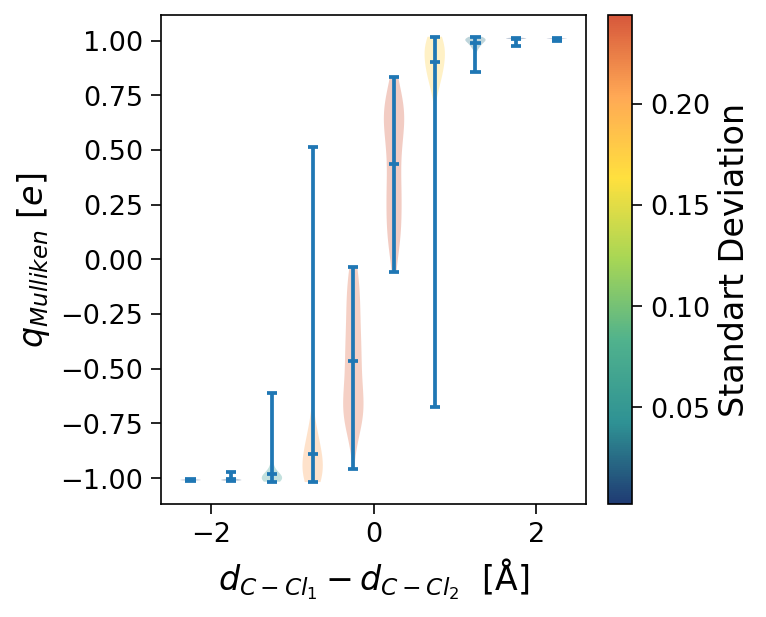

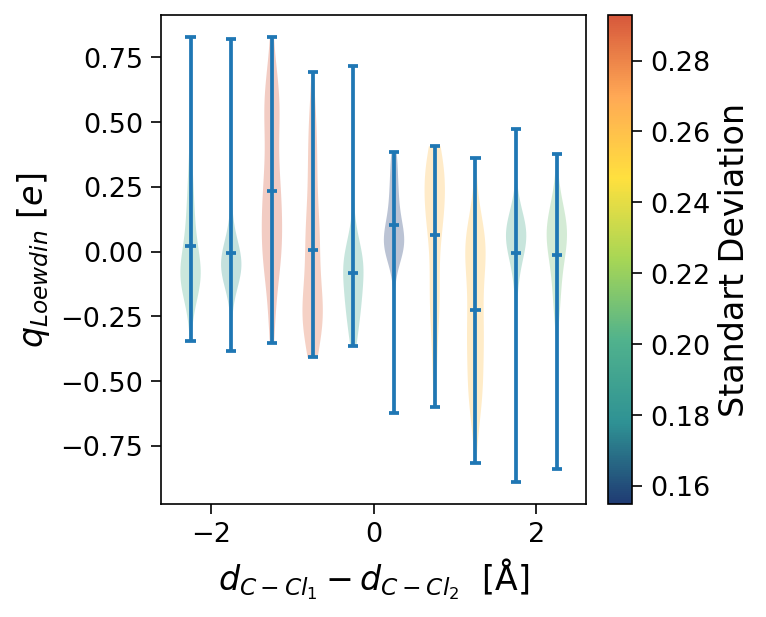

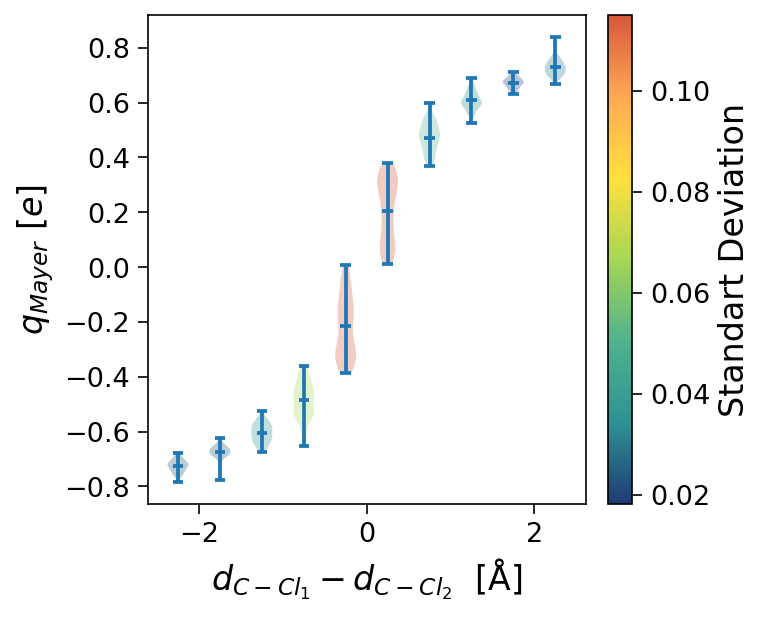

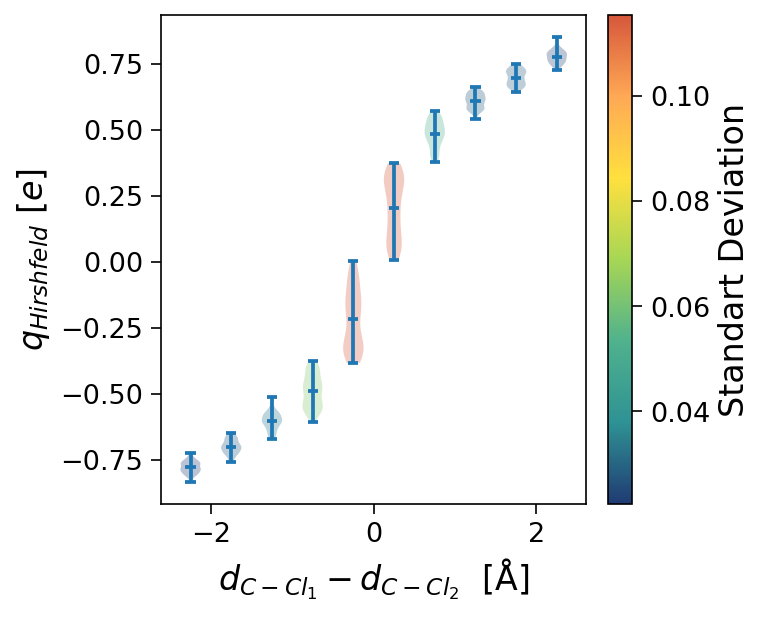

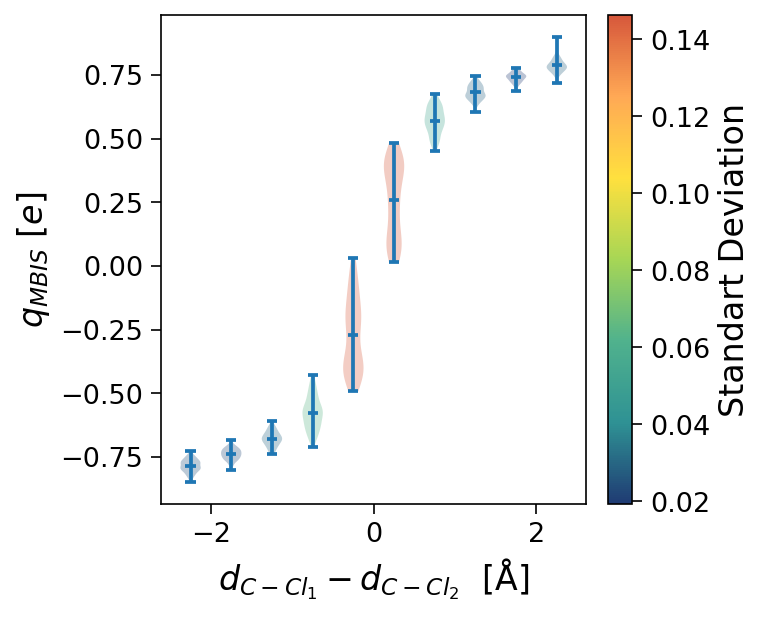

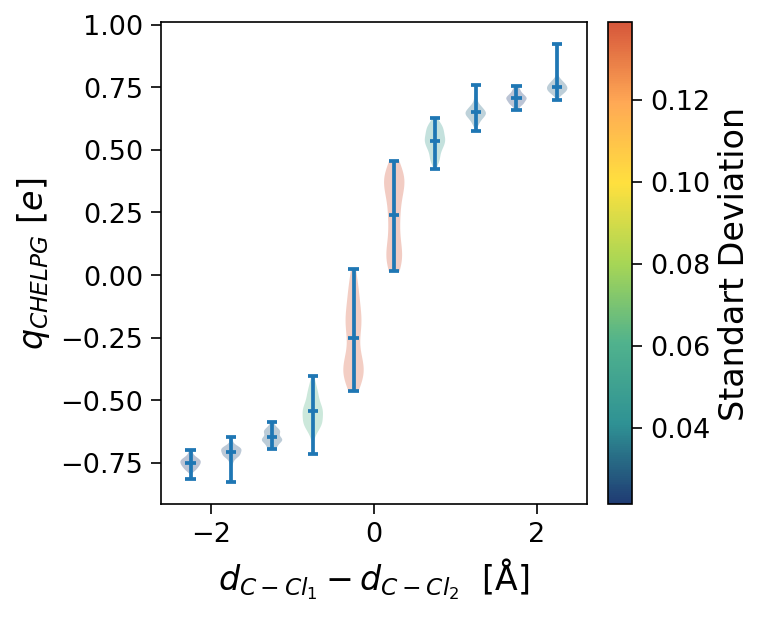

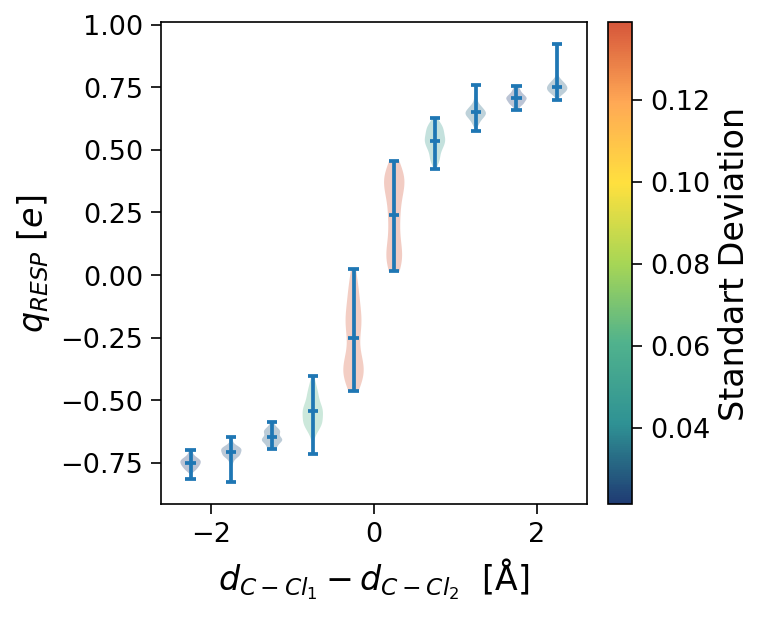

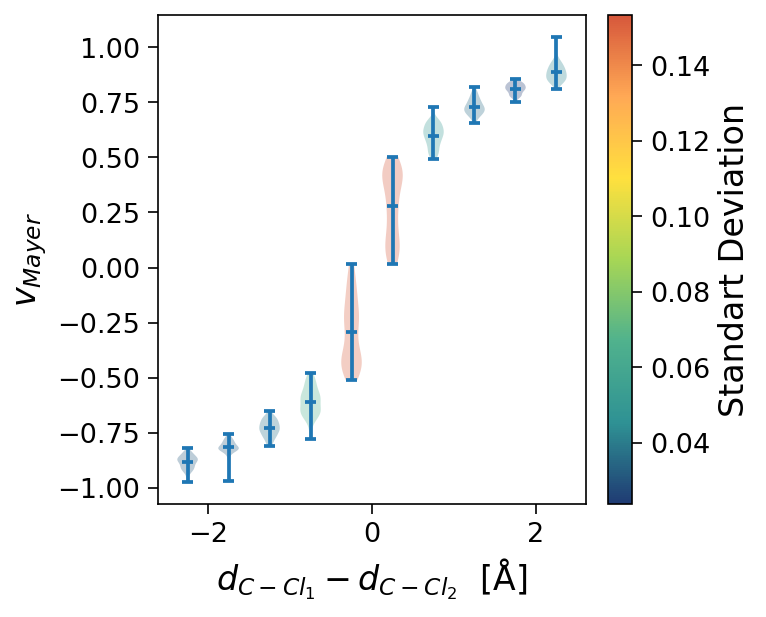

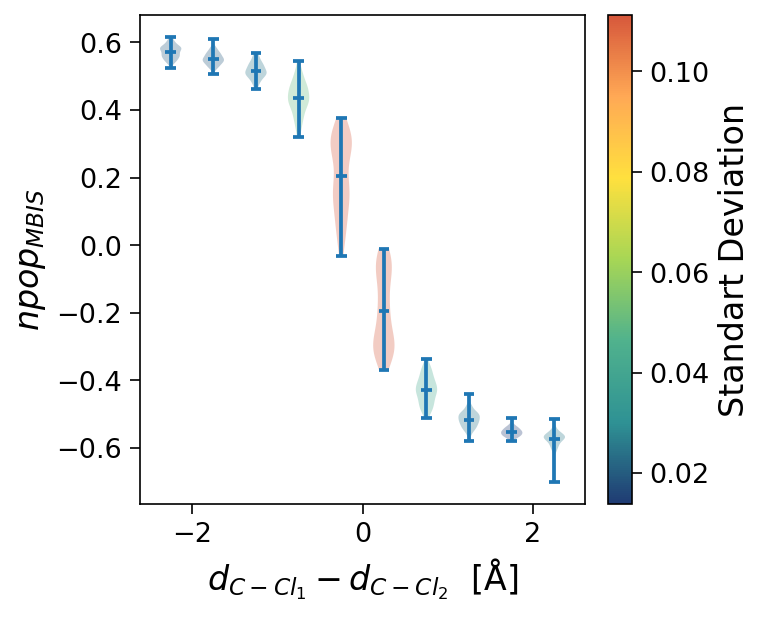

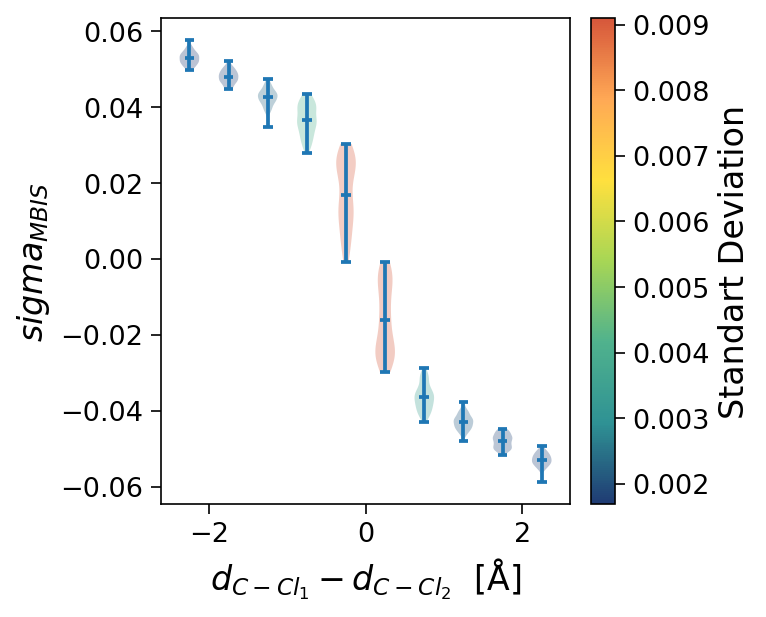

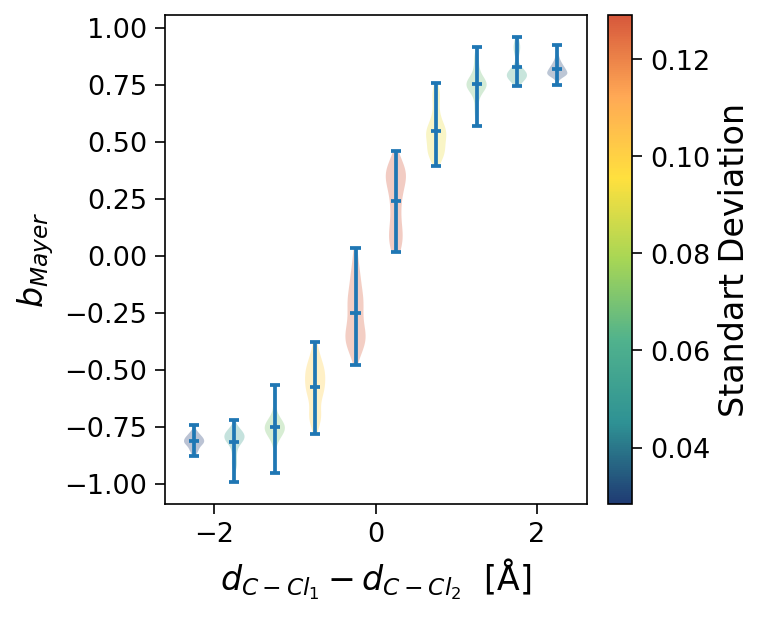

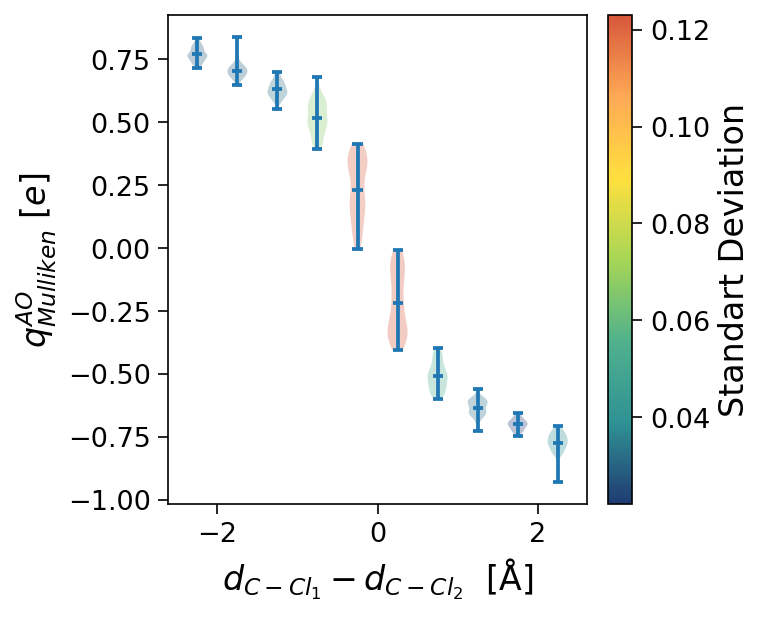

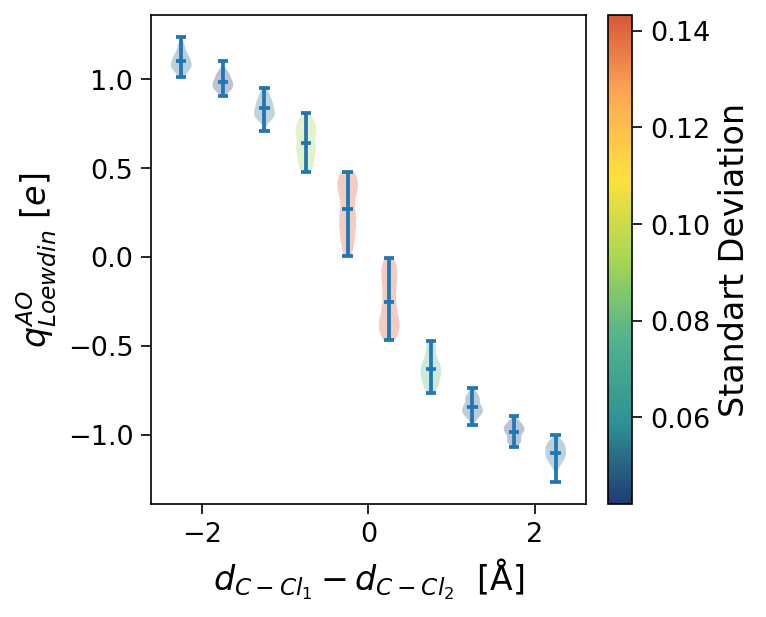

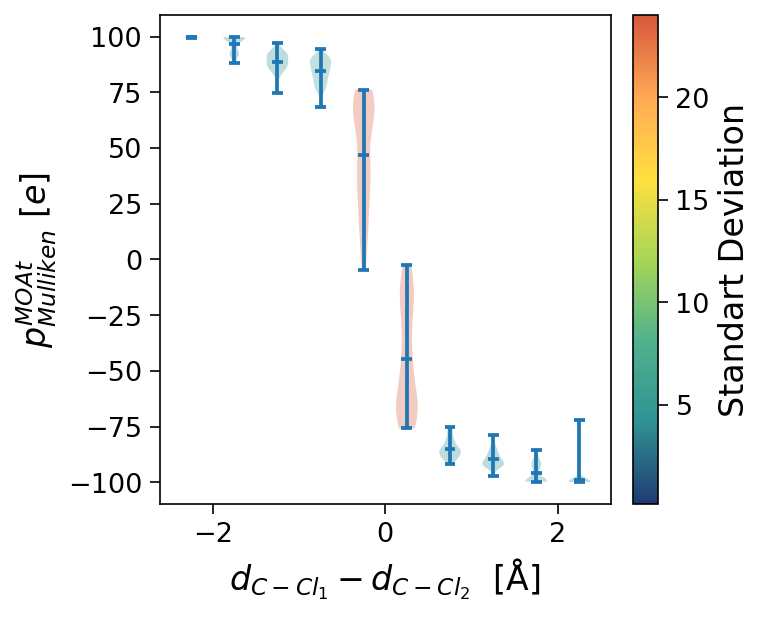

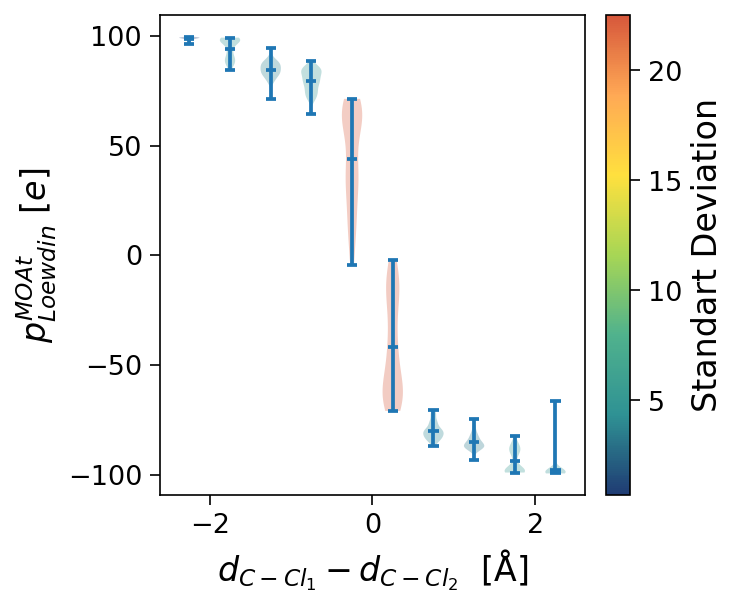

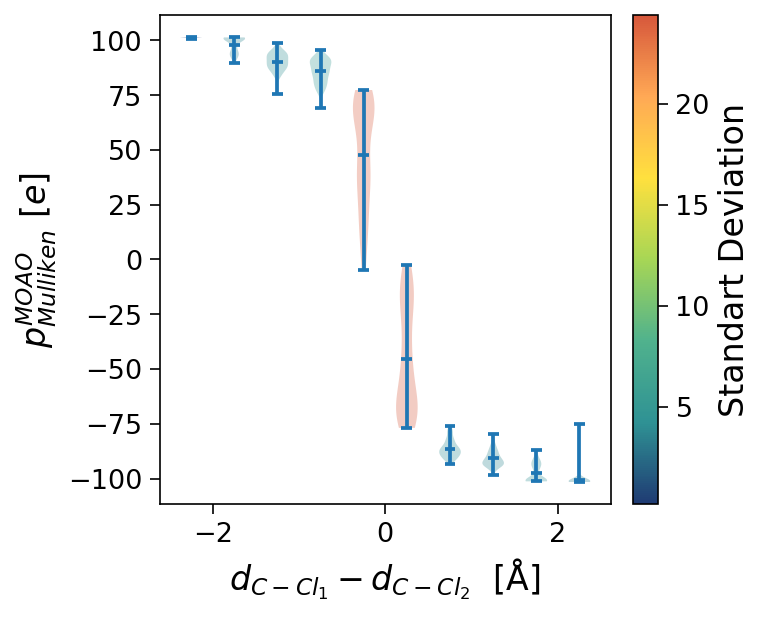

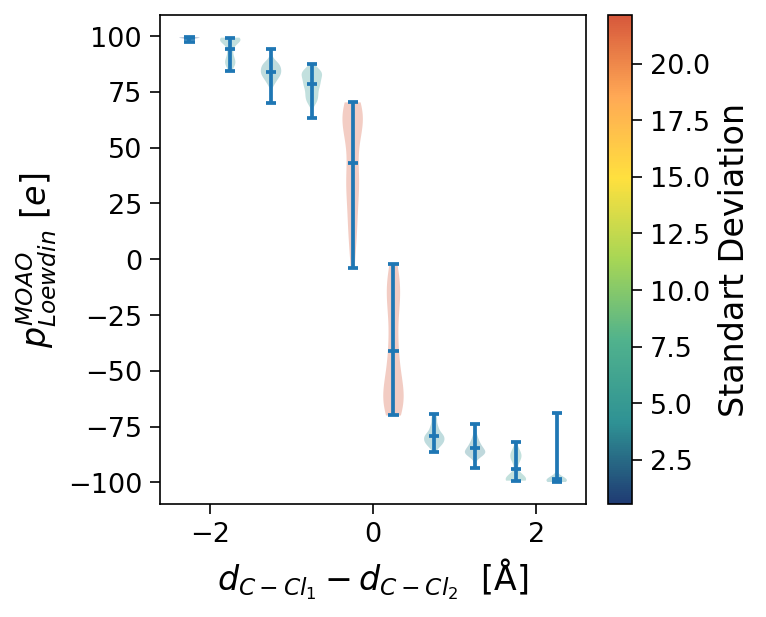

In [5]:
for key, chemcv in chemcvs.items():
    bins, dataset = helpers.bin_2D(
        geomcv,
        chemcv, 
        nb_bins=10,
        bounds=(-2.5, 2.5),
    )
    err = np.std(dataset, axis=1)
    fig = figures.violin_correlation(
        bins,
        dataset,
        xlabel=r"$d_{C-Cl_1} - d_{C-Cl_2}$  [Å]",
        ylabel=labels[key],
        color=err,
        color_label=r"Standart Deviation"
    )
    fig.savefig(f"SAMPLING/violin_dd/{key}.svg")